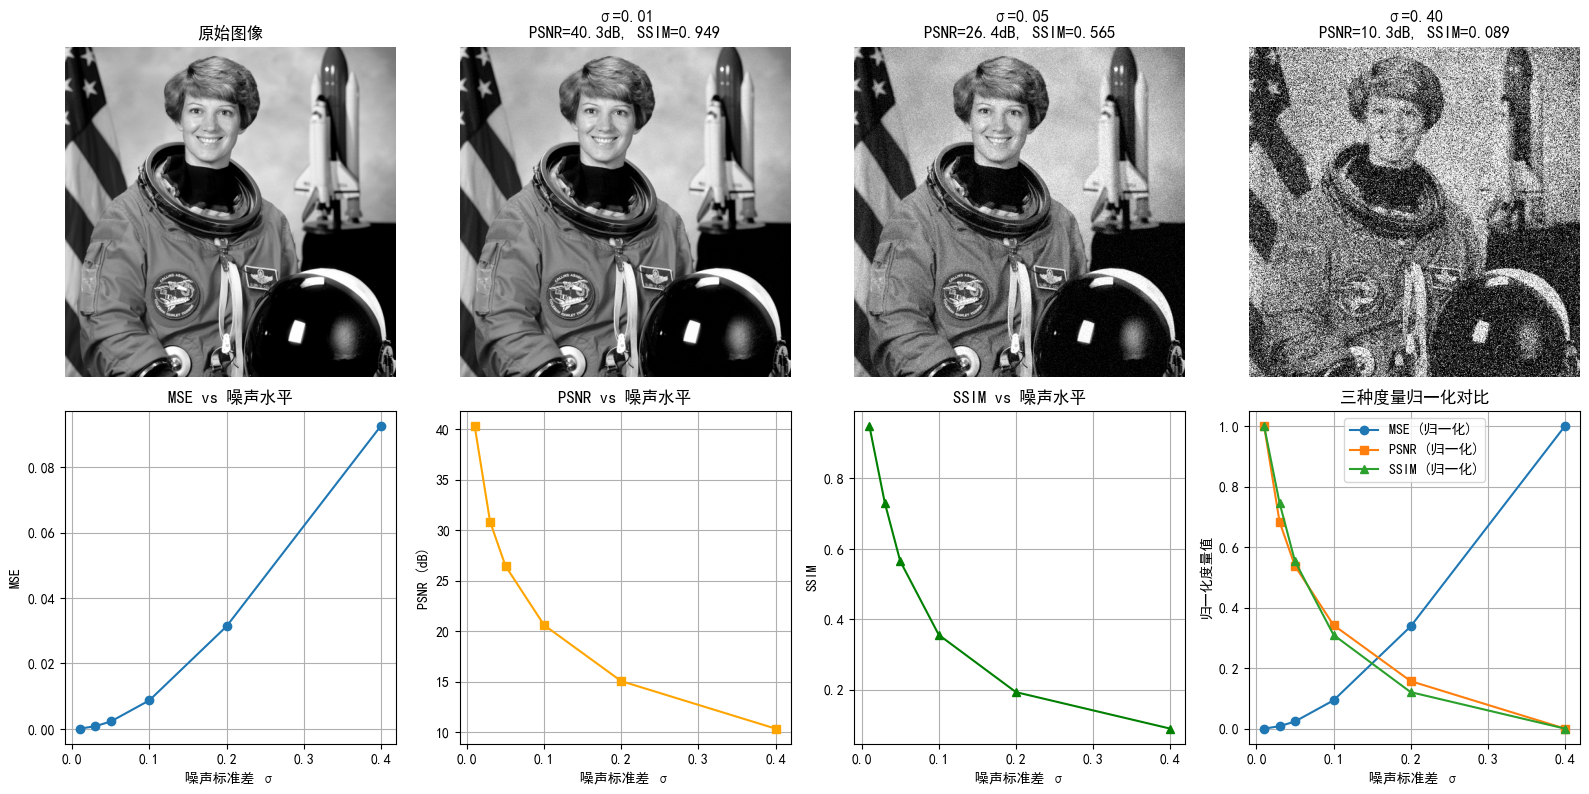

     σ         MSE    PSNR(dB)      SSIM
------------------------------------------
  0.01    0.000093       40.31    0.9486
  0.03    0.000828       30.82    0.7303
  0.05    0.002269       26.44    0.5645
  0.10    0.008731       20.59    0.3552
  0.20    0.031332       15.04    0.1926
  0.40    0.092552       10.34    0.0890


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import astronaut, shepp_logan_phantom
from skimage.color import rgb2gray
from skimage.transform import resize
from skimage.metrics import (
    mean_squared_error,
    peak_signal_noise_ratio,
    structural_similarity,
)
from skimage.util import random_noise
np.random.seed(42) 
# ====== 解决中文乱码的核心代码（必须加在画图之前） ======
plt.rcParams['font.sans-serif'] = ['SimHei']  # 强制使用黑体 显示中文
plt.rcParams['axes.unicode_minus'] = False    # 解决坐标轴负号显示问题
# ========================================================


# ---- 1. 加载并预处理图像 ----
x_color = astronaut()
x = rgb2gray(x_color)  # 转为灰度，值域 [0, 1]

# ---- 2. 添加不同水平的高斯噪声 ----
noise_levels = [0.01, 0.03, 0.05, 0.10, 0.20, 0.40]
noisy_images = []
for sigma in noise_levels:
    y = x + sigma * np.random.randn(*x.shape)
    y = np.clip(y, 0, 1)
    noisy_images.append(y)

# ---- 3. 计算三种质量度量 ----
mse_vals, psnr_vals, ssim_vals = [], [], []
for y in noisy_images:
    mse_vals.append(mean_squared_error(x, y))
    psnr_vals.append(peak_signal_noise_ratio(x, y))
    ssim_vals.append(structural_similarity(x, y, data_range=1.0))

# ---- 4. 可视化 ----
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# 第一行：原始图像 + 3 个噪声示例
axes[0, 0].imshow(x, cmap='gray', vmin=0, vmax=1)
axes[0, 0].set_title('原始图像')
axes[0, 0].axis('off')

for i, idx in enumerate([0, 2, 5]):
    axes[0, i + 1].imshow(noisy_images[idx], cmap='gray', vmin=0, vmax=1)
    axes[0, i + 1].set_title(f'σ={noise_levels[idx]:.2f}\nPSNR={psnr_vals[idx]:.1f}dB, SSIM={ssim_vals[idx]:.3f}')
    axes[0, i + 1].axis('off')

# 第二行：度量随噪声水平的变化曲线

axes[1, 0].plot(noise_levels, mse_vals, 'o-')
axes[1, 0].set_xlabel('噪声标准差 σ')
axes[1, 0].set_ylabel('MSE')
axes[1, 0].set_title('MSE vs 噪声水平')
axes[1, 0].grid(True)

axes[1, 1].plot(noise_levels, psnr_vals, 's-', color='orange')
axes[1, 1].set_xlabel('噪声标准差 σ')
axes[1, 1].set_ylabel('PSNR (dB)')
axes[1, 1].set_title('PSNR vs 噪声水平')
axes[1, 1].grid(True)

axes[1, 2].plot(noise_levels, ssim_vals, '^-', color='green')
axes[1, 2].set_xlabel('噪声标准差 σ')
axes[1, 2].set_ylabel('SSIM')
axes[1, 2].set_title('SSIM vs 噪声水平')
axes[1, 2].grid(True)

# 对比三种度量的归一化趋势
mse_norm = (np.array(mse_vals) - min(mse_vals)) / (max(mse_vals) - min(mse_vals) + 1e-10)
psnr_norm = (np.array(psnr_vals) - min(psnr_vals)) / (max(psnr_vals) - min(psnr_vals) + 1e-10)
ssim_norm = (np.array(ssim_vals) - min(ssim_vals)) / (max(ssim_vals) - min(ssim_vals) + 1e-10)
axes[1, 3].plot(noise_levels, mse_norm, 'o-', label='MSE (归一化)')
axes[1, 3].plot(noise_levels, psnr_norm, 's-', label='PSNR (归一化)')
axes[1, 3].plot(noise_levels, ssim_norm, '^-', label='SSIM (归一化)')
axes[1, 3].set_xlabel('噪声标准差 σ')
axes[1, 3].set_ylabel('归一化度量值')
axes[1, 3].set_title('三种度量归一化对比')
axes[1, 3].legend()
axes[1, 3].grid(True)

plt.tight_layout()
plt.savefig('实验1_1_质量评估.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- 5. 打印数值结果 ----
print(f"{'σ':>6s}  {'MSE':>10s}  {'PSNR(dB)':>10s}  {'SSIM':>8s}")
print("-" * 42)
for i, sigma in enumerate(noise_levels):
    print(f"{sigma:6.2f}  {mse_vals[i]:10.6f}  {psnr_vals[i]:10.2f}  {ssim_vals[i]:8.4f}")